# Notebook 06 — Segmentation Overlays

Visualises MedSAM predictions on the test set.
One row per scanner center — shows domain generalisation.
Red=Prediction | Green=GT | Yellow=Overlap

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.cuda.amp import autocast
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve().parent
paths        = json.loads((PROJECT_ROOT / 'paths.json').read_text())
PREPROCESSED = Path(paths['preprocessed'])
SPLITS_DIR   = PROJECT_ROOT / 'splits'
EXPERIMENTS  = Path(paths['experiments'])
MEDSAM_CKPT  = paths['medsam_ckpt']
FIGURES      = PROJECT_ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

for p in [str(PROJECT_ROOT), str(Path(paths['fed7_root']))]:
    if p not in sys.path:
        sys.path.insert(0, p)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_df = pd.read_csv(SPLITS_DIR / 'test.csv')
print(f'Test patients: {test_df["patient_id"].nunique()}')
print(f'Device: {DEVICE}')

Test patients: 42
Device: cuda


In [2]:
# Load MedSAM best checkpoint
from models.medsam.model import MedSAMMultiTask

EXP       = 'exp09_medsam_fullaug'
ckpt_path = EXPERIMENTS / EXP / 'checkpoint_best.pt'

assert ckpt_path.exists(), (
    f'Run exp09 in Notebook 03 first.\nNot found: {ckpt_path}'
)

ckpt  = torch.load(str(ckpt_path), map_location=DEVICE)
model = MedSAMMultiTask(
    medsam_checkpoint=MEDSAM_CKPT,
    in_channels=5,
    freeze_encoder=False,
)
model.load_state_dict(ckpt['state'], strict=False)
model = model.to(DEVICE)
model.eval()

ep  = ckpt.get('epoch', 0) + 1
m   = ckpt.get('metrics', {})
print(f'Loaded {EXP} (epoch {ep})')
print(f'Val DSC={m.get("tumour_dsc",0):.4f} | AUC={m.get("auc",0):.4f}')

C:\Users\Mayank\AppData\Local\Temp\ipykernel_1284352\3572880514.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(str(ckpt_path), map_location=DEVICE)


[MedSAM] resized pos_embed -> torch.Size([1, 16, 16, 768])
[MedSAM-MultiTask] in_ch=5 | freeze_enc=False | params=88,483,004
Loaded exp09_medsam_fullaug (epoch 85)
Val DSC=0.7075 | AUC=0.7054


In [3]:
# Build dataset and pick one tumor slice per center
from datasets.fedbca_dataset import FedBCaDataset

ds = FedBCaDataset(
    test_df, str(PREPROCESSED),
    mode='val', model_type='cnn',
    use_augmentation=False,
)

selected = {}
for i in range(len(ds)):
    s = ds[i]
    c = s['center']
    ht = s['has_tumor'].item() if hasattr(s['has_tumor'], 'item') else int(s['has_tumor'])
    if ht and c not in selected:
        selected[c] = i
    if len(selected) == 4:
        break

print(f'Selected slices: {selected}')

Selected slices: {1: 3, 2: 279, 3: 391, 4: 446}


C:\Users\Mayank\AppData\Local\Temp\ipykernel_1284352\75895876.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


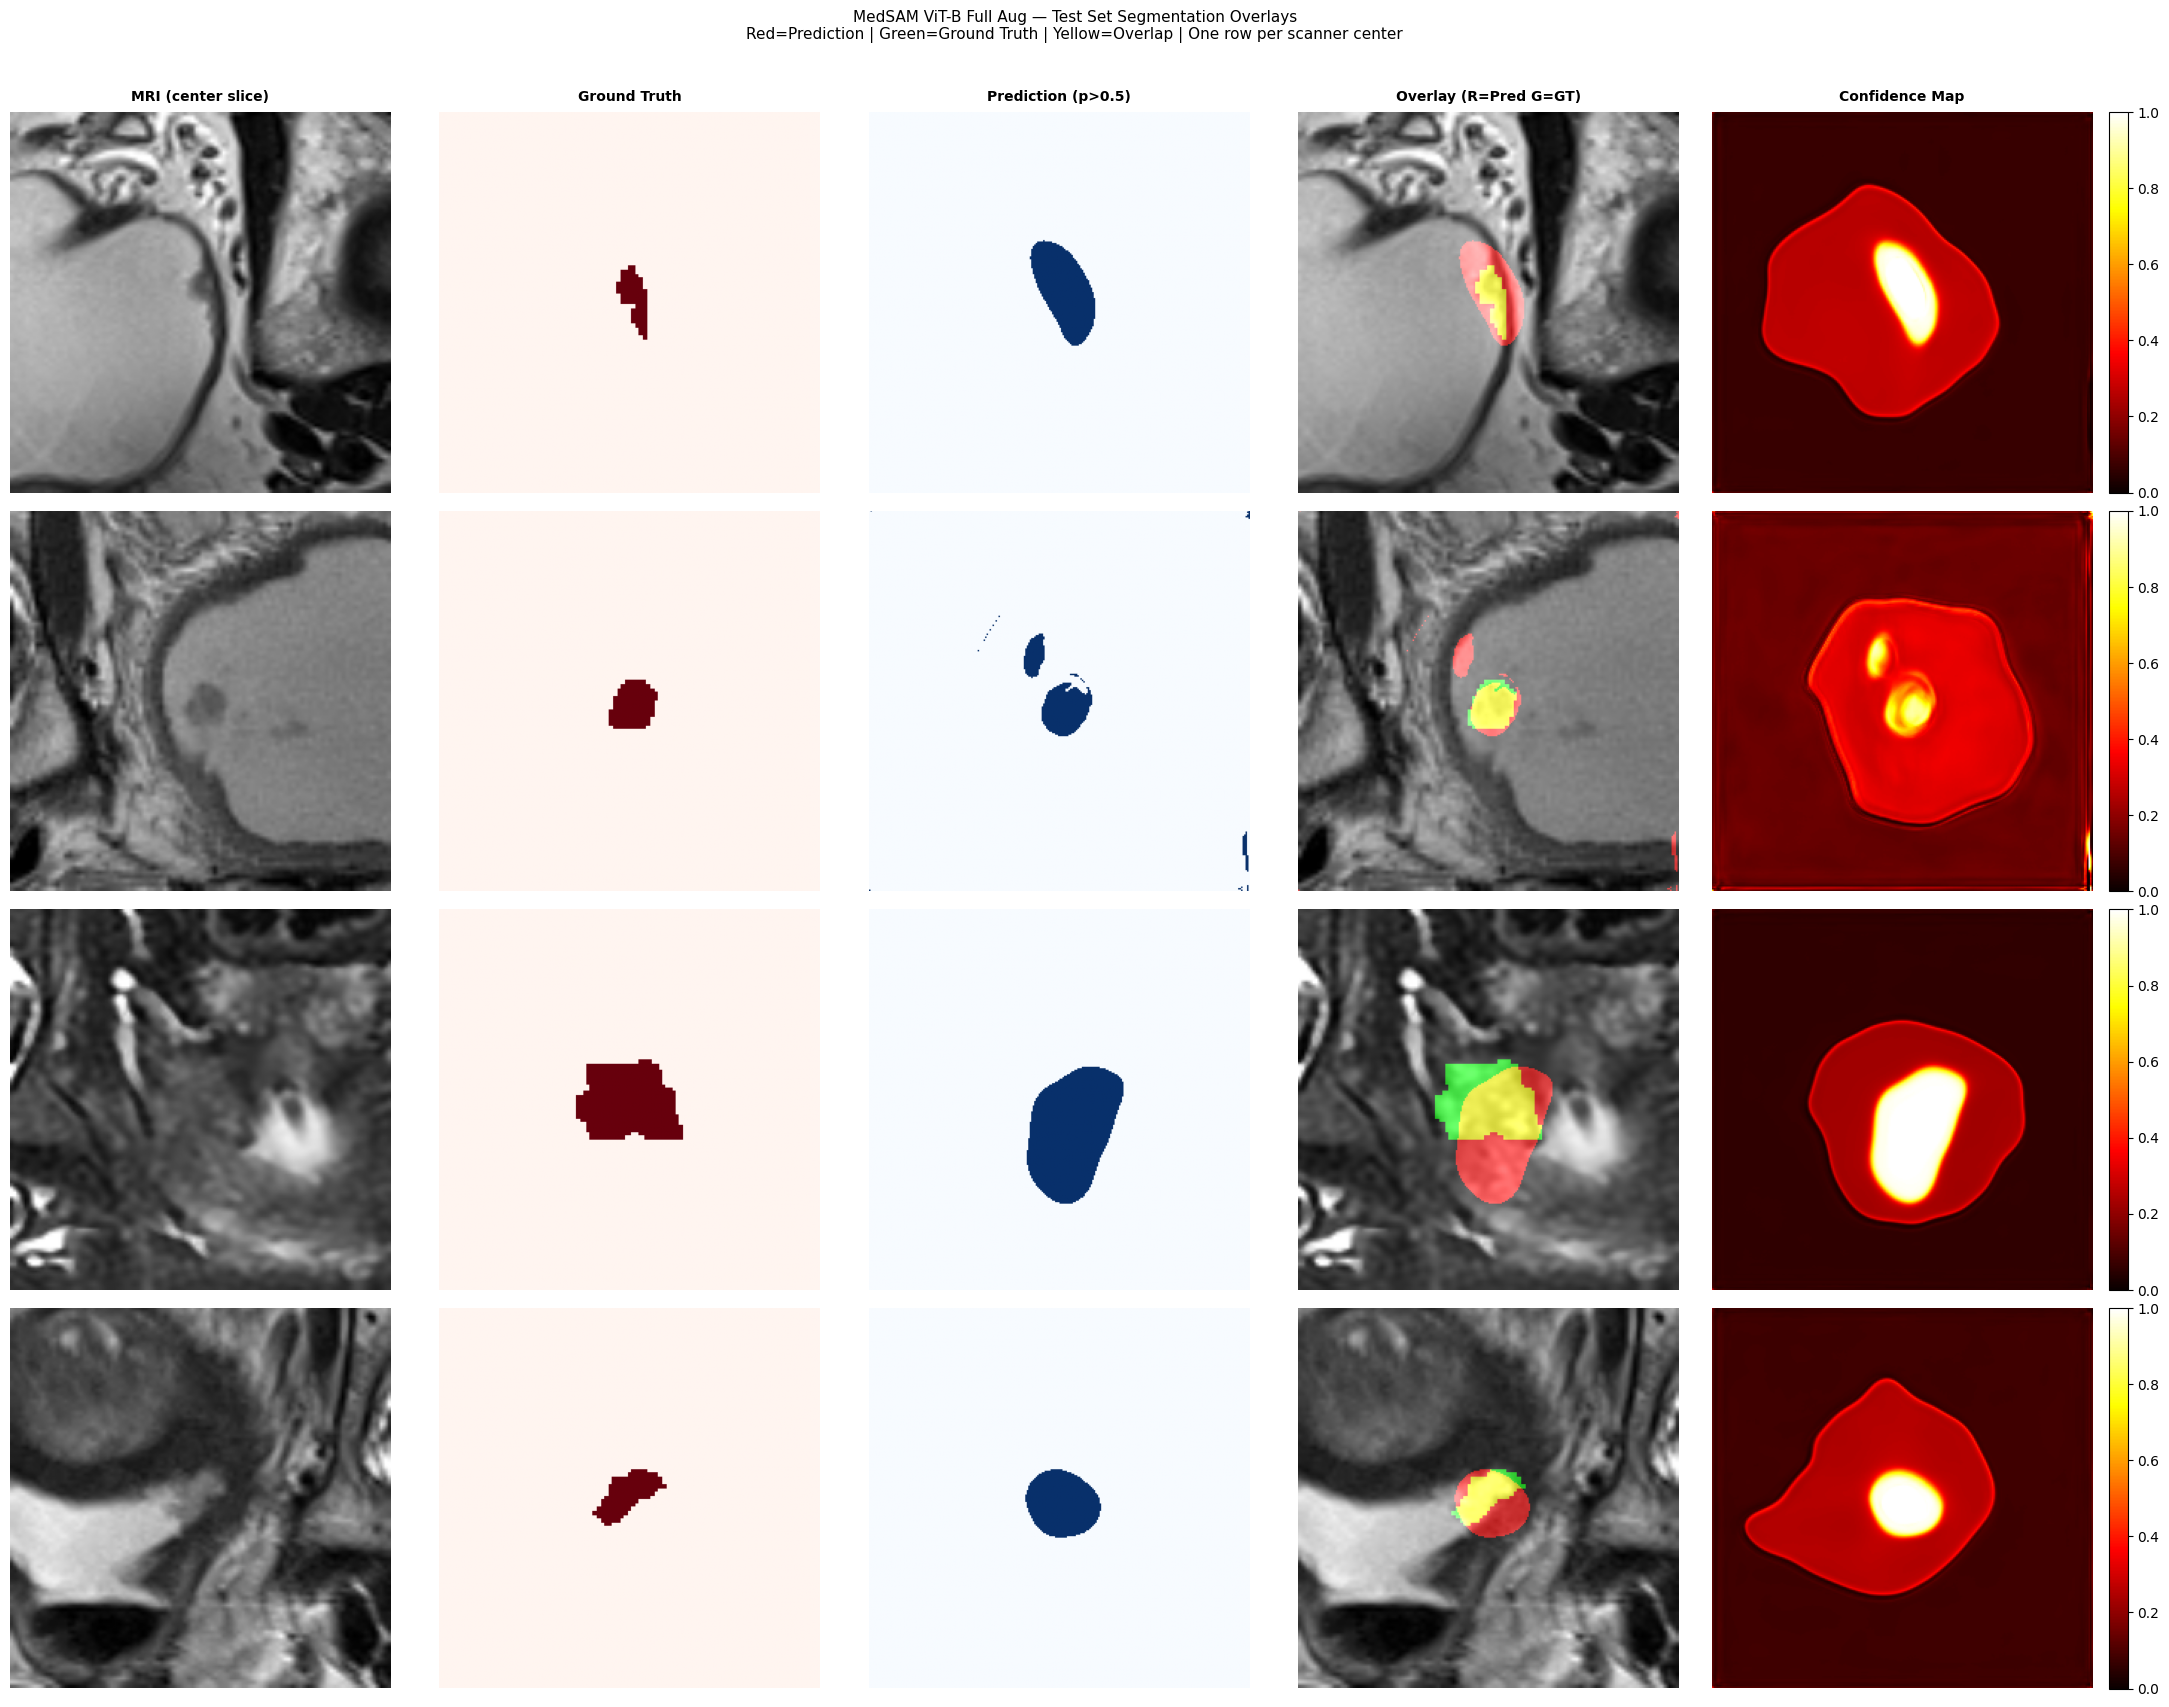

Saved: C:\Users\Mayank\Desktop\fedbca_medsam_complete\fedbca_medsam\figures\segmentation_overlays.png


In [4]:
# Generate and save overlay figure
n_show = len(selected)
fig, axes = plt.subplots(n_show, 5, figsize=(22, n_show * 4.2))
if n_show == 1:
    axes = axes[np.newaxis, :]

col_titles = ['MRI (center slice)', 'Ground Truth',
              'Prediction (p>0.5)', 'Overlay (R=Pred G=GT)', 'Confidence Map']
for ci, t in enumerate(col_titles):
    axes[0, ci].set_title(t, fontsize=10, fontweight='bold', pad=8)

with torch.no_grad():
    for row, (center, idx) in enumerate(sorted(selected.items())):
        s    = ds[idx]
        imgs = s['image'].unsqueeze(0).to(DEVICE)
        mask = s['mask'].numpy()[0]
        lv   = s['label'].item()

        with autocast(enabled=True):
            out  = model(imgs)
            prob = torch.sigmoid(out['seg'][0, 0]).cpu().numpy()
            prob = np.nan_to_num(prob, nan=0.0, posinf=1.0, neginf=0.0)
            pred = (prob > 0.5).astype(np.uint8)
            cls_p = torch.softmax(out['cls'], dim=1)[0, 1].item()

        mri  = s['image'].numpy()[2]
        disp = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)

        # Overlay: R=prediction, G=GT, Y=both
        ov = np.stack([disp, disp, disp], axis=-1).copy()
        ov[pred > 0, 0] = np.clip(ov[pred > 0, 0] + 0.6, 0, 1)
        ov[mask > 0, 1] = np.clip(ov[mask > 0, 1] + 0.6, 0, 1)

        true_lbl = 'MIBC'  if lv >= 1      else 'NMIBC'
        pred_lbl = 'MIBC'  if cls_p >= 0.5 else 'NMIBC'
        correct  = 'CORRECT' if true_lbl == pred_lbl else 'WRONG'

        inter     = (pred * mask).sum()
        union     = pred.sum() + mask.sum()
        slice_dsc = float(2 * inter / (union + 1e-5))

        axes[row, 0].imshow(disp, cmap='gray')
        axes[row, 0].set_ylabel(
            f'Center {center}\n'
            f'True: {true_lbl}\n'
            f'Pred: {pred_lbl} ({correct})\n'
            f'DSC: {slice_dsc:.3f}',
            fontsize=9, rotation=0, labelpad=90
        )
        axes[row, 1].imshow(mask, cmap='Reds',  vmin=0, vmax=1)
        axes[row, 2].imshow(pred, cmap='Blues', vmin=0, vmax=1)
        axes[row, 3].imshow(ov)
        im = axes[row, 4].imshow(prob, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row, 4], fraction=0.046, pad=0.04)

        for ax in axes[row]:
            ax.axis('off')

plt.suptitle(
    'MedSAM ViT-B Full Aug — Test Set Segmentation Overlays\n'
    'Red=Prediction | Green=Ground Truth | Yellow=Overlap | '
    'One row per scanner center',
    fontsize=11, y=1.01
)
plt.tight_layout()
out_path = FIGURES / 'segmentation_overlays.png'
plt.savefig(str(out_path), dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')